# 3.1 · plan_ego — 자차는 어디로 가는가

앞으로 3초의 자차 경로를 예측합니다. 정답이 egomotion 센서 측정값에서 직접 나오므로 이 데이터셋에서 가장 신뢰도 높은 타깃입니다.

이 노트북은 네 가지를 확인합니다 — **어떤 원시 데이터에서**, **어떤 코드를 거쳐**, **무엇이 입력으로 들어가고**, **빌드된 파일이 그 코드와 일치하는지**. GPU 는 필요 없습니다.

In [1]:
import os, sys, json, textwrap
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd

from datatools import paths

ITEMS = os.path.join(paths.COMMON_DIR, "instruct_items_tasks01_06.parquet")
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)
wrap = lambda s, i="   ": textwrap.fill(str(s), 94, initial_indent=i,
                                        subsequent_indent=i)
VARIANTS = ['plan_ego_xy', 'plan_ego_control']
print("variants:", VARIANTS)

variants: ['plan_ego_xy', 'plan_ego_control']


## 1. 어떤 원시 데이터에서 오는가

| 아카이브 | 주기 | 읽는 것 |
|---|---|---|
| `egomotion` | 10 Hz | x, y, qx..qw — 이것 하나로 정답이 만들어집니다 |
| `radar` | 20 / 12.7 Hz | 2초 창 20스캔. 앞차의 감속을 읽는 데 쓰입니다 |
| `camera` | 1 Hz | 2장. 신호등·정지선·커브가 운전자 의도를 정합니다 |

## 2. 어떤 코드를 거치는가

실행 순서입니다.

| 함수 | 하는 일 |
|---|---|
| `ego_frame(ego)` | 속도, 가속도, 요, 요레이트 파생 |
| `ego_waypoints(derived, t_s)` | t+1/2/3초 위치를 현재 자차 좌표계로 회전 변환 |
| `ego_controls(derived, t_s)` | 같은 궤적을 속도·요레이트로 |
| `ego_action(derived, t_s)` | CoT 용 기동 분류 |

전부 `datatools/frame_objects.py` 와 `datatools/geometry.py` 에 있습니다.

In [2]:
import inspect
from datatools import frame_objects as F
for name in ['ego_frame', 'ego_waypoints', 'ego_controls', 'ego_action']:
    fn = getattr(F, name, None)
    if fn is None:
        from datatools import geometry as G
        fn = getattr(G, name, None)
    if fn is None or not callable(fn):
        print(f'{name}: (모듈 함수 아님)'); continue
    doc = (inspect.getdoc(fn) or '').split(chr(10))[0]
    print(f'{name:34s} {doc[:80]}')

ego_frame                          Ego pose and dynamics on the egomotion clock.
ego_waypoints                      Future ego offsets in the ego frame at `t_s`, forward-positive.
ego_controls                       The same trajectory as a control sequence: future speed and yaw rate.
ego_action                         The manoeuvre the ego actually performs over the prediction horizon.


## 3. 입력으로 무엇이 들어가는가

**비전 2장 (1 fps) · 레이더 20스캔 (2초, 10 Hz) · ego 20샘플**

입력 창은 태스크마다 다릅니다. 로더의 `WINDOWS` 표가 그것을 정하고, 레이더는 항상 20스캔이라 창의 길이가 바뀌면 샘플링 속도가 따라 바뀝니다 — 인코더 입력 모양은 변하지 않습니다.

In [3]:
from training.instruct_data import WINDOWS, INSTANT_TASKS, WINDOW_TASKS
for v in VARIANTS:
    for name in (v, v + "_cot"):
        if name in WINDOWS:
            secs, hz, frames = WINDOWS[name]
            print(f"{name:26s} 창 {secs}초 · 레이더 {hz} Hz × 20스캔 · 비전 {frames}장")
        elif name in INSTANT_TASKS:
            print(f"{name:26s} 순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1")
        else:
            print(f"{name:26s} 클립 전체 — 비전 20장 · 레이더 20스캔/20초")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


plan_ego_xy                창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
plan_ego_xy_cot            창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
plan_ego_control           창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장
plan_ego_control_cot       창 2초 · 레이더 10 Hz × 20스캔 · 비전 2장


## 4. 예제 10건 — 원시 입력째로

`notebooks/example_data/` 에 테스크마다 10건이 들어 있습니다. **parquet 도 원본 아카이브도 필요 없습니다.**

| 경로 | 내용 |
|---|---|
| `gen_data/<task>.jsonl` | LLM 학습에 쓰이는 아이템 그대로 — instruction, ego, 정답, 근거 |
| `raw/<task>/NN/frames/` | 그 아이템에 실제로 들어가는 프레임 |
| `raw/<task>/NN/radar.npz` | 그 창의 레이더 반사점 (패딩 제거) |

평문 변형과 CoT 변형은 같은 아이템입니다 — CoT 정답의 `answer` 필드가 평문 정답과 글자 그대로 같아서, 한 건이 둘을 모두 보여줍니다.

In [4]:
import glob
EX = os.path.abspath(os.path.join(os.getcwd(), "..", "example_data"))
examples = {}
for v in VARIANTS:
    path = os.path.join(EX, "gen_data", v + ".jsonl")
    examples[v] = [json.loads(l) for l in open(path)] if os.path.exists(path) else []
    print(f"{v:26s} {len(examples[v]):>2}건")
rows = [{"id": r["id"], "clip": r["clip_id"][:8], "프레임": r["n_frames"],
         "레이더 점": r["radar_points"], "정답 길이": len(r["target"]),
         "근거 길이": len(r["rationale"])}
        for v in VARIANTS for r in examples[v]]
pd.DataFrame(rows)

plan_ego_xy                10건
plan_ego_control           10건


,id,clip,프레임,레이더 점,정답 길이,근거 길이
0,plan_ego_xy/00,4712a251,2,3795,53,118
1,plan_ego_xy/01,93988904,2,6111,52,123
2,plan_ego_xy/02,f358f2a5,2,2937,52,123
3,plan_ego_xy/03,7b95fc60,2,3657,55,125
4,plan_ego_xy/04,e2ee3b38,2,2849,52,123
5,plan_ego_xy/05,6dd872ce,2,18759,55,125
6,plan_ego_xy/06,3eae939d,2,16333,54,118
7,plan_ego_xy/07,79341781,2,10262,52,123
8,plan_ego_xy/08,52748d01,2,3923,52,121
9,plan_ego_xy/09,ec5c720d,2,5628,52,123


한 건을 통째로 봅니다. instruction 이 출력 형식을 고르고, 근거가 그 형식의 답으로 이어집니다.

In [5]:
pool = examples[VARIANTS[0]]
# 예제는 전방 레이더가 있는 클립에서만 뽑았다. 데이터 전체로는 177,891 클립 중
# 17,130건(9.6%)이 전방 레이더가 없고, 그 조건에서는 아래 그림이 빈 채로 나온다.
r = next((x for x in pool if x["radar_points"]), pool[0])
if not r["radar_points"]:
    print("!! 이 예제는 전방 레이더가 없는 클립입니다 (반사점 0개)")
print("=" * 96)
print(f"{r['id']}   clip {r['clip_id'][:8]}   {r['sensors']}")
print(f"창: {r['window']}")
print()
print("instruction:"); print(wrap(r["instruction"].replace(chr(10), " | ")))
print("ego:");         print(wrap(r["ego"]))
print("answer (GT):"); print(wrap(r["target"]))
print("rationale:");   print(wrap(r["rationale"]))

plan_ego_xy/00   clip 4712a251   Sensors present: camera, ego motion, short-range radar.
창: {'kind': 'window', 'seconds': 2, 'radar_hz': 10, 'video_frames': 2}

instruction:
   At frame 10. Predict the ego vehicle's path over the next 3 seconds as (x, y) offsets in
   metres.
ego:
   Ego motion (binned, 2 s at 10 Hz, ending at t=9s): t0:s1a15y15 t1:s1a15y15 t2:s1a16y15
   t3:s1a16y15 t4:s1a16y15 t5:s1a18y15 t6:s1a20y15 t7:s1a21y15 t8:s2a22y15 t9:s2a24y15
   t10:s2a27y15 t11:s2a28y15 t12:s3a28y15 t13:s3a28y15 t14:s3a26y15 t15:s3a26y15 t16:s4a25y15
   t17:s4a22y15 t18:s4a20y15 t19:s4a20y14
answer (GT):
   +1s (+4.8, -0.1); +2s (+9.5, -0.1); +3s (+13.2, -0.2)
rationale:
   The ego vehicle is travelling at 4.6 m/s and will brake and go straight. At that speed it
   covers about 5 m per second.


그 아이템에 실제로 들어가는 프레임과 레이더 반사점입니다. 레이더는 자차 기준 좌표(x 전방, y 좌)이고 색이 시선속도 — 정지 물체는 자차 속도의 음수로 모여 보입니다.

프레임 2장 · 반사점 3795개 · 채널 ['x', 'y', 'z', 'radial_velocity', 'doppler_residual', 'rcs', 'snr', 'range']


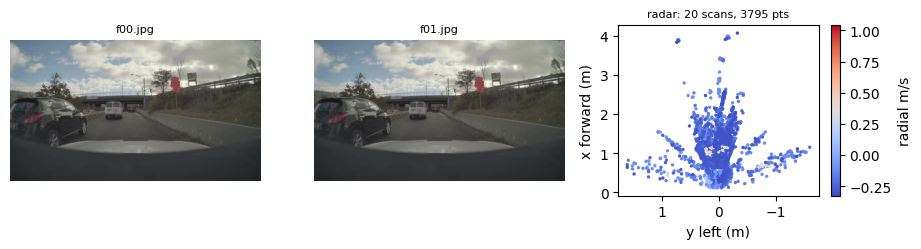

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

d = os.path.join(EX, r["raw"])
paths = sorted(glob.glob(os.path.join(d, "frames", "*.jpg")))
z = np.load(os.path.join(d, "radar.npz"))
pts, ch = z["points"].astype(np.float32), [str(c) for c in z["channels"]]
print(f"프레임 {len(paths)}장 · 반사점 {len(pts)}개 · 채널 {ch}")

fig, axes = plt.subplots(1, len(paths) + 1, figsize=(3.1 * (len(paths) + 1), 2.6))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
ax = axes[-1]
# 그림 안 글자는 ASCII 로 둔다. matplotlib 의 기본 폰트에 한글 글리프가 없어
# 라벨이 네모로 나오고, 폰트 등록을 요구하면 노트북이 기계를 가린다.
if len(pts):
    s = ax.scatter(pts[:, ch.index("y")], pts[:, ch.index("x")], s=2,
                   c=pts[:, ch.index("radial_velocity")], cmap="coolwarm")
    ax.set_title(f"radar: {r['radar_scans']} scans, {len(pts)} pts", fontsize=8)
    ax.invert_xaxis(); fig.colorbar(s, ax=ax, label="radial m/s")
else:
    ax.text(0.5, 0.5, "no returns", ha="center", va="center")
    ax.set_title("clip has no forward radar", fontsize=8)
ax.set_xlabel("y left (m)"); ax.set_ylabel("x forward (m)")
plt.tight_layout(); plt.show()

## 5. 빌드된 파일의 실제 아이템

여기서부터는 parquet 이 있는 기계에서만 돕니다. 위의 예제가 빌드 전체와 같은 규칙으로 만들어졌는지 확인하는 절입니다.

In [7]:
built = pd.read_parquet(ITEMS)
for v in VARIANTS:
    sub = built[built.task == v]
    if sub.empty:
        print(f"{v}: 파일에 없음"); continue
    r = sub.iloc[0]
    print("=" * 96)
    print(f"{v}   clip {r.clip_id[:8]}  frame {r.frame} (t={r.frame-1}s)  split {r.split}")
    print("Q:"); print(wrap(r.prompt))
    print("A:"); print(wrap(r.target))

plan_ego_xy   clip 1f47bf7f  frame 4 (t=3s)  split train
Q:
   Predict the ego vehicle's path over the next 3 seconds as (x, y) offsets in metres.
A:
   +1s (+7.3, -0.8); +2s (+15.6, -2.6); +3s (+24.4, -4.4)
plan_ego_control   clip 1f47bf7f  frame 4 (t=3s)  split train
Q:
   Predict the ego vehicle's speed and yaw rate over the next 3 seconds.
A:
   +1s 8.0 m/s, yaw -5.3 deg/s; +2s 8.7 m/s, yaw +1.3 deg/s; +3s 9.4 m/s, yaw +0.6 deg/s


## 6. CoT — 근거가 답을 만드는가

`_cot` 변형은 `{"rationale": ..., "answer": ...}` 입니다. **근거를 따라가면 답이 나와야** 합니다. 나오지 않으면 그 사슬은 잘못된 것이고, 보상을 걸면 모델이 그 잘못된 사슬을 배웁니다.

In [8]:
for v in VARIANTS:
    name = v + "_cot"
    sub = built[built.task == name] if 'built' in dir() else None
    if sub is None or sub.empty:
        continue
    r = sub.iloc[0]
    d = json.loads(r.target)
    print("=" * 96); print(name)
    print("R:"); print(wrap(d["rationale"]))
    print("A:"); print(wrap(d["answer"]))

plan_ego_xy_cot
R:
   The ego vehicle is travelling at 6.8 m/s and will accelerate and turn right. At that speed
   it covers about 7 m per second.
A:
   +1s (+7.3, -0.8); +2s (+15.6, -2.6); +3s (+24.4, -4.4)
plan_ego_control_cot
R:
   The ego vehicle is travelling at 6.8 m/s and will accelerate and turn right. At that speed
   it covers about 7 m per second.
A:
   +1s 8.0 m/s, yaw -5.3 deg/s; +2s 8.7 m/s, yaw +1.3 deg/s; +3s 9.4 m/s, yaw +0.6 deg/s


## 7. 보상

평가 채점기에서 유도했습니다. 정답을 그대로 넣으면 1.0 이 나와야 하고, 내용을 망가뜨리면 떨어져야 합니다.

In [9]:
import re
from training.task_scorers import reward_for

def wreck(text):
    """형식은 두고 숫자만 2배로."""
    return re.sub(r"\d+(?:\.\d+)?",
                  lambda m: str(round(float(m.group()) * 2, 1)), text)

rows = []
for v in VARIANTS:
    for name in (v, v + "_cot"):
        fn = reward_for(name)
        if fn is None:
            continue
        sub = built[built.task == name] if 'built' in dir() else None
        if sub is None or sub.empty:
            continue
        t = sub.iloc[0].target
        rows.append({"task": name, "reward": fn.__name__,
                     "정답": round(fn(t, t), 3),
                     "숫자 2배": round(fn(wreck(t), t), 3)})
pd.DataFrame(rows)

,task,reward,정답,숫자 2배
0,plan_ego_xy,reward_waypoints,1.0,0.00
1,plan_ego_xy_cot,reward_with_rationale[plan_ego_xy],1.0,0.15
2,plan_ego_control,reward_control,1.0,0.00
3,plan_ego_control_cot,reward_with_rationale[plan_ego_control],1.0,0.15


## 8. 데이터 양

`val` 은 `train` 에 합쳐져 있습니다 — 클립 분할이 train 86,607 / val 54,163 / test 37,121 인데, 모델 선택은 `test` 에서 하므로 검증용 3분의 1이 쓰이지 않고 있었습니다.

In [10]:
from collections import Counter
from training.instruct_data import load_items
names = [v for v in VARIANTS] + [v + "_cot" for v in VARIANTS]
rows = []
for split in ("train", "test"):
    c = Counter(i["task"] for i in load_items(tuple(names), split))
    for n in names:
        rows.append({"task": n, "split": split, "items": c.get(n, 0)})
pd.DataFrame(rows).pivot(index="task", columns="split", values="items")

split,test,train
task,,
plan_ego_control,247247,1006678
plan_ego_control_cot,247247,1006678
plan_ego_xy,247247,1006678
plan_ego_xy_cot,247247,1006678


## 9. 이 태스크에서 내린 결정과 근거

**등속 외삽으로는 부족**

현재 속도 × 시간으로 외삽하면 오차 중앙값 1.09 m 이고 보상의 반점 기준(1 m) 안에 드는 것이 47.9% 뿐입니다. 감속과 조향을 예측해야 하고, 그건 장면에 달려 있습니다.

**앵커 2초 간격**

1초 간격이면 인접 정답 차이가 중앙값 0.72 m 로 반점 기준보다 작아 같은 문항의 반복이 됩니다. 2초면 1.42 m 로 넘어섭니다.

**t=17 이 마지막**

18+3=21초는 클립 밖입니다.

**근거가 레이더가 아닌 유일한 태스크**

내가 어디로 갈지는 내 속도와 조향이 정합니다. 레이더 개입이 여기까지 영향을 준다면 그것은 레이더 능력이 아니라는 신호입니다.